# 0 · Descarga y exploración inicial de datos

> **Proyecto:** `CyberForest`  
> **Tipo de ML:** `supervisado`  
> **Autor:** `Alejandro Cancelas Chapela`


## 1. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from cyberforest.utils.paths import RAW_DATA_DIR, FIGURES_DIR
from cyberforest.data.make_dataset import load_data

# ── Estilo global ─────────────────────────────────────────────────────────
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(' Imports OK')


 Imports OK


## 2. Carga de datos

Coloca el CSV en `data/raw/` y ajusta `DATA_FILE` y `TARGET_COL`.

In [2]:
# Configuración de carga de datos
TARGET_COL = 'Label'      # ← nombre real de la columna objetivo en CIC-IDS2017

# Cargar y combinar todos los DataFrames
df = load_data()
df.head(10)

--> Cargando Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
--> Cargando Monday-WorkingHours.pcap_ISCX.csv...
--> Cargando Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
--> Cargando Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
--> Cargando Tuesday-WorkingHours.pcap_ISCX.csv...
--> Cargando Wednesday-workingHours.pcap_ISCX.csv...

    Total combinado: (2413965, 79)
    Clases: {'BENIGN': 1986312, 'DoS Hulk': 231073, 'PortScan': 158930, 'DoS GoldenEye': 10293, 'FTP-Patator': 7938, 'SSH-Patator': 5897, 'DoS slowloris': 5796, 'DoS Slowhttptest': 5499, 'Web Attack � Brute Force': 1507, 'Web Attack � XSS': 652, 'Infiltration': 36, 'Web Attack � Sql Injection': 21, 'Heartbleed': 11}


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,...,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.976,109.865,976,0,158.045,312.675,7595.105,67.122,15075.500,104051.400,948537,0,1266342,31658.550,159355.259,996324,2,...,158.045,1328,0,0,0,0,0,0,41,2664,44,6954,29200,243,24,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.976,109.865,976,0,158.045,312.675,7289.937,64.426,15706.583,104861.870,955790,1,1319353,32983.825,159247.901,996423,1,...,158.045,1328,0,0,0,0,0,0,41,2664,44,6954,29200,243,24,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,12500.000,160.000,0.000,160,160,0,0.000,0.000,0,0,...,0.000,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.537,110.130,976,0,157.952,319.121,7182.268,63.675,15896.195,106554.899,956551,0,1303488,32587.200,160397.050,997357,1,...,157.952,1328,0,0,0,0,0,0,41,2728,42,6634,29200,243,24,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,38961.039,38.500,14.849,49,28,0,0.000,0.000,0,0,...,0.000,32,0,0,0,0,0,0,1,0,2,0,243,290,0,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
5,22,244,1,1,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,8196.721,244.000,0.000,244,244,0,0.000,0.000,0,0,...,0.000,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
6,22,1307239,41,40,2728,6634,456,0,66.537,110.130,976,0,165.850,325.142,7161.659,61.963,16340.487,107311.879,956263,0,1307239,32680.975,159066.994,997887,1,...,165.850,1328,0,0,0,0,0,0,41,2728,40,6634,29200,243,24,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
7,60058,82,1,2,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,36585.366,41.000,11.314,49,33,0,0.000,0.000,0,0,...,0.000,32,0,0,0,0,0,0,1,0,2,0,243,290,0,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
8,22,171,1,1,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,11695.906,171.000,0.000,171,171,0,0.000,0.000,0,0,...,0.000,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
9,22,210,1,1,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,9523.810,210.000,0.000,210,210,0,0.000,0.000,0,0,...,0.000,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN


## 3. Inspección general

In [3]:
print(f'Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
df.info()


Shape: 2,413,965 filas × 79 columnas
Memoria: 1564.23 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2413965 entries, 0 to 2413964
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std              

In [4]:
# Estadísticas descriptivas completas (transpuesta para mejor lectura)
df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination Port,2413965.000000,nan,nan,nan,8100.005831,18255.163755,0.000000,53.000000,80.000000,443.000000,65535.000000
Flow Duration,2413965.000000,nan,nan,nan,14898048.340500,34052919.724086,-13.000000,110.000000,30578.000000,1359427.000000,119999998.000000
Total Fwd Packets,2413965.000000,nan,nan,nan,9.427321,750.767393,1.000000,1.000000,2.000000,5.000000,219759.000000
Total Backward Packets,2413965.000000,nan,nan,nan,10.461730,996.591178,0.000000,1.000000,2.000000,4.000000,291922.000000
Total Length of Fwd Packets,2413965.000000,nan,nan,nan,508.808192,10542.405747,0.000000,6.000000,64.000000,299.000000,12900000.000000
Total Length of Bwd Packets,2413965.000000,nan,nan,nan,16149.423895,2266330.186002,0.000000,0.000000,120.000000,416.000000,655453030.000000
Fwd Packet Length Max,2413965.000000,nan,nan,nan,179.254403,492.679013,0.000000,6.000000,38.000000,189.000000,24820.000000
Fwd Packet Length Min,2413965.000000,nan,nan,nan,17.446003,40.302961,0.000000,0.000000,2.000000,37.000000,2293.000000
Fwd Packet Length Mean,2413965.000000,nan,nan,nan,48.731288,120.541186,0.000000,6.000000,35.000000,51.000000,4672.000000
Fwd Packet Length Std,2413965.000000,nan,nan,nan,56.738158,170.432256,0.000000,0.000000,0.000000,54.112845,7125.596846


In [5]:
# Columnas numéricas y categóricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

feat_num = [c for c in num_cols if c != TARGET_COL]


print(f'Numéricas ({len(num_cols)}): {num_cols}')
print(f'Categóricas ({len(cat_cols)}): {cat_cols}')

if TARGET_COL in df.columns:
    print(f'\nBalance de clases ({TARGET_COL}):')
    print(df[TARGET_COL].value_counts())
    print(df[TARGET_COL].value_counts(normalize=True).map('{:.1%}'.format))



Numéricas (78): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count',

## Balance de clases

El dataset presenta un desbalanceo severo: BENIGN representa el 82.3% de las muestras,
lo que distorsionaría cualquier modelo entrenado directamente sobre los datos originales.

Para abordarlo se aplica una estrategia de **clasificación jerárquica en dos etapas**:

**Modelo 1 — clasificador principal**
Distingue entre las clases con suficiente representación y una categoría `Other`
que agrupa los ataques minoritarios. Umbral mínimo: 500 muestras.

**Modelo 2 — clasificador secundario**
Entrenado únicamente sobre las muestras clasificadas como `Other` por el modelo 1.
Desglosa los tipos de ataque con volumen suficiente para generalizar.

**Clases descartadas**
Heartbleed (11), Web Attack – Sql Injection (21) e Infiltration (36) se excluyen
del entrenamiento por no tener muestras suficientes para aprender patrones reales.
Incluirlas introduciría ruido y riesgo de memorización.

In [6]:
# Duplicados
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup} ({n_dup/len(df):.1%})')
# Después de df = load_data(None) y concatenar
print(f"Antes de limpiar: {df.shape}")
df = df.drop_duplicates()
print(f"Después de limpiar: {df.shape}")


Filas duplicadas: 281860 (11.7%)
Antes de limpiar: (2413965, 79)
Después de limpiar: (2132105, 79)


## 4. Valores nulos

`missingno` usa un mapa de calor blanco/negro por filas: blanco = nulo, negro = valor presente.
Si las columnas nulas forman patrones, los nulos no son aleatorios (MNAR).

In [7]:
null_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje': df.isnull().mean().map('{:.1%}'.format),
    'Tipo': df.dtypes
}).sort_values('Nulos', ascending=False)

null_df = null_df[null_df['Nulos'] > 0]
if null_df.empty:
    print(' Sin valores nulos')
else:
    display(null_df.style.background_gradient(cmap='Reds', subset=['Nulos']))


,Nulos,Porcentaje,Tipo
Flow Bytes/s,322,0.0%,float64


In [ ]:
df[df["Label"] == "BENIGN"].isnull().any(axis=1).sum()

al ser un dataset tan grande y desbalanceado se borraran esas 377 columnas 

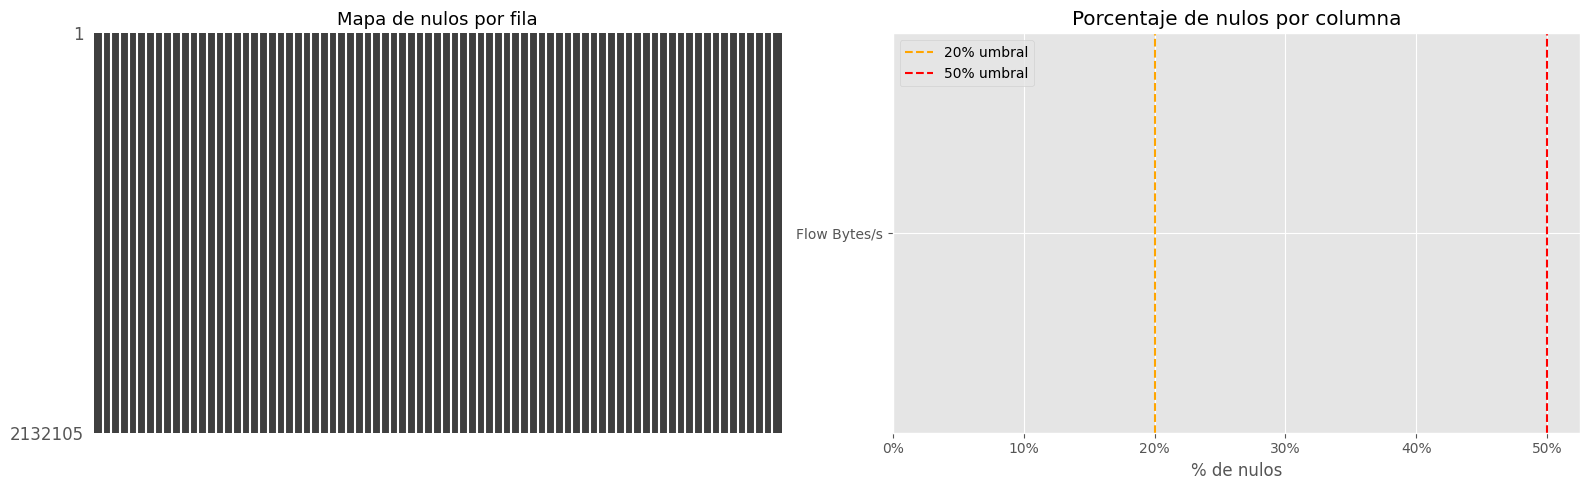

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Matriz de nulos (missingno)
msno.matrix(df, ax=axes[0], sparkline=False, fontsize=10)
axes[0].set_title('Mapa de nulos por fila', fontsize=13)

# Barplot de % de nulos por columna
pct_null = df.isnull().mean().sort_values(ascending=False)
pct_null = pct_null[pct_null > 0]
if not pct_null.empty:
    axes[1].barh(pct_null.index, pct_null.values * 100, color='tomato', edgecolor='white')
    axes[1].axvline(20, color='orange', lw=1.5, linestyle='--', label='20% umbral')
    axes[1].axvline(50, color='red', lw=1.5, linestyle='--', label='50% umbral')
    axes[1].set_xlabel('% de nulos')
    axes[1].set_title('Porcentaje de nulos por columna')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
else:
    axes[1].text(0.5, 0.5, 'Sin nulos ', ha='center', va='center', fontsize=14,
                 transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


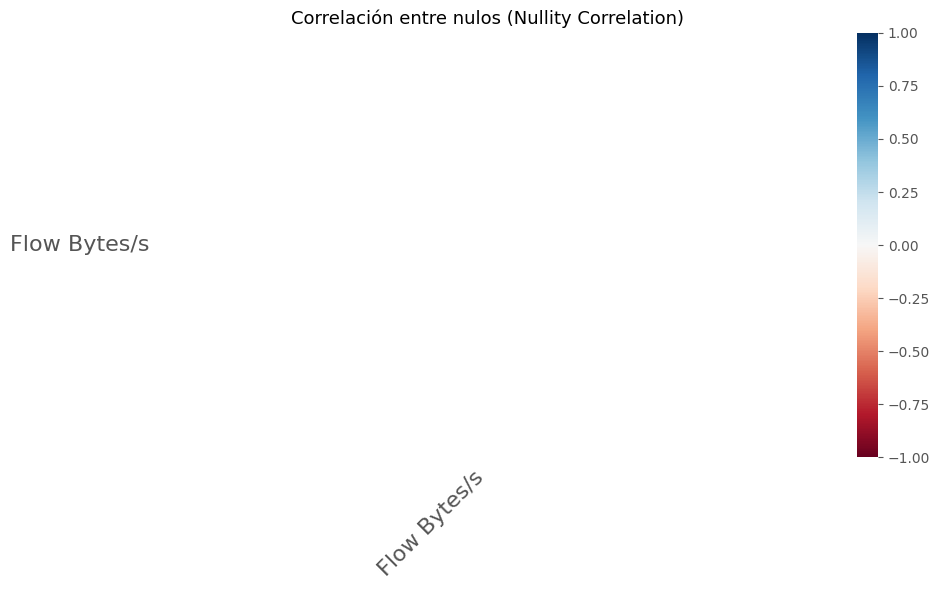

In [9]:
# Mapa de calor de correlación entre nulos
# Si dos columnas tienen nulos correlacionados → probablemente se originan juntos
if df.isnull().any().any():
    msno.heatmap(df, figsize=(10, 6))
    plt.title('Correlación entre nulos (Nullity Correlation)', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'nullity_heatmap.png', dpi=150)
    plt.show()


In [10]:
df.dropna(inplace=True)

## 5. Distribuciones + KDE

Histograma + curva KDE superpuesta para detectar:
- Sesgos (skewness)
- Multimodalidad (varias 'jorobas' = posibles subpoblaciones)
- Distribuciones muy concentradas

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
target_encoded = le.fit_transform(df[TARGET_COL])

In [12]:
# Calcular correlación entre cada característica numérica y la variable objetivo codificada
correlaciones = df[feat_num].corrwith(pd.Series(target_encoded, index=df.index))

In [13]:
# Seleccionar las 15 características numéricas más correlacionadas (en valor absoluto)
top_features = correlaciones.abs().sort_values(ascending=False).head(15).index.tolist()

In [14]:
# Reemplazar inf por NaN y limpiar columnas problemáticas
df.replace([np.inf, -np.inf], np.nan, inplace=True)

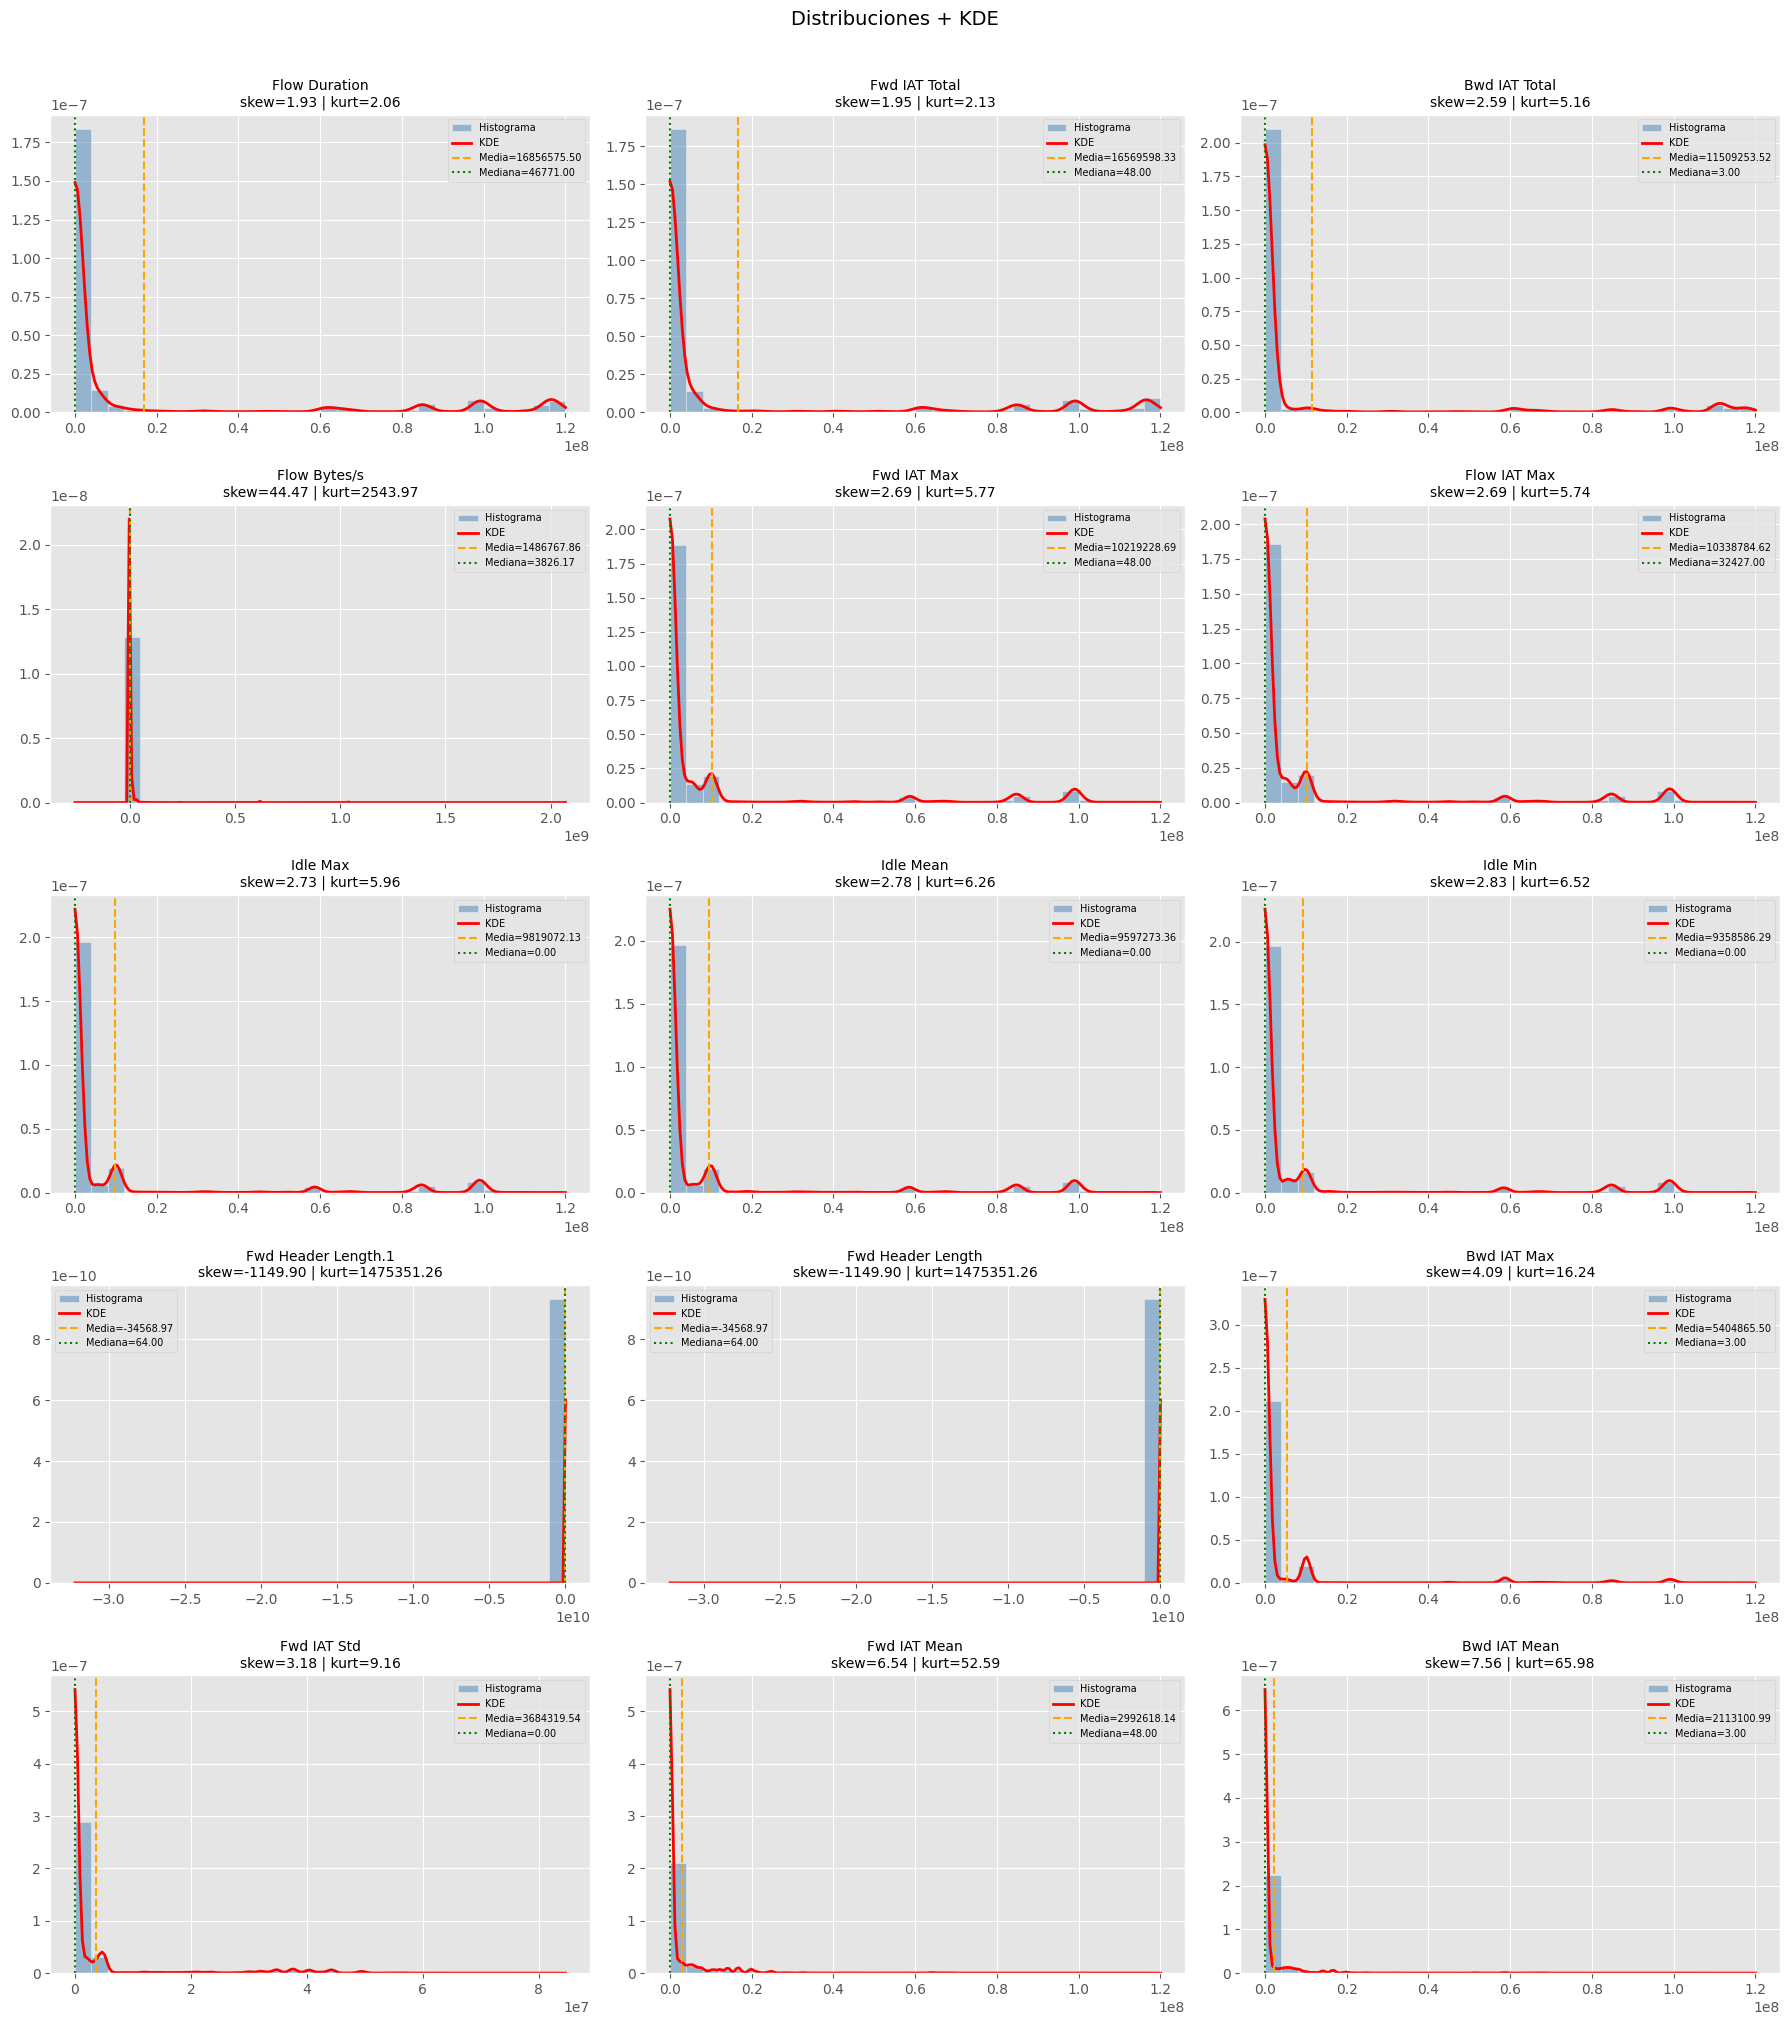

In [15]:
# Top 15 numéricas por varianza (más varianza = más informativa)
if feat_num:
    variances = df[feat_num].var().sort_values(ascending=False)
    feat_num = variances.head(15).index.tolist()
if feat_num:
    n_cols_plot = min(3, len(feat_num))
    n_rows_plot = int(np.ceil(len(feat_num) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(6 * n_cols_plot, 4 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(feat_num):
        data = df[col].dropna()
        skew = data.skew()
        kurt = data.kurt()

        axes[i].hist(data, bins=30, density=True, alpha=0.5,
                     color='steelblue', edgecolor='white', label='Histograma')

        # KDE
        kde_x = np.linspace(data.min(), data.max(), 200)
        kde = stats.gaussian_kde(data)
        axes[i].plot(kde_x, kde(kde_x), 'r-', lw=2, label='KDE')

        # Líneas de media y mediana
        axes[i].axvline(data.mean(),   color='orange', lw=1.5, linestyle='--', label=f'Media={data.mean():.2f}')
        axes[i].axvline(data.median(), color='green',  lw=1.5, linestyle=':',  label=f'Mediana={data.median():.2f}')

        axes[i].set_title(f'{col}\nskew={skew:.2f} | kurt={kurt:.2f}', fontsize=10)
        axes[i].legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribuciones + KDE', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'distributions_kde.png', dpi=150, bbox_inches='tight')
    plt.show()


Columnas a eliminar directamente:

    Fwd Header Length.1 y Fwd Header Length — skew=-1149, kurt=1.4M, valores negativos de -32 billones. Columnas corruptas, drop inmediato.

    Flow Bytes/s — skew=44, valores imposibles. Drop.

Columnas con skew extremo que necesitan log1p:

    Fwd IAT Mean (skew=6.54), Bwd IAT Mean (skew=7.56), Fwd IAT Std (skew=3.18), Bwd IAT Max (skew=4.09) — todas con masa en cero y cola larga. Candidatas a log1p.

    Idle Mean, Idle Max, Idle Min — mediana=0, la mayoría de flujos no tienen tiempo idle. Mucha masa en cero, log1p.

    Flow Duration, Fwd IAT Total, Bwd IAT Total — skew moderado (~2), distribución bimodal visible. Log1p ayuda pero no es crítico.

In [16]:
# Resumen de asimetría y curtosis
skew_kurt = pd.DataFrame({
    'Skewness': df[feat_num].skew(),
    'Kurtosis': df[feat_num].kurt()
}).sort_values('Skewness', key=abs, ascending=False)

skew_kurt.style \
    .background_gradient(cmap='RdYlGn_r', subset=['Skewness']) \
    .background_gradient(cmap='Blues',    subset=['Kurtosis']) \
    .format('{:.3f}')


,Skewness,Kurtosis
Fwd Header Length,-1149.904,1475351.258
Fwd Header Length.1,-1149.904,1475351.258
Flow Bytes/s,44.472,2543.972
Bwd IAT Mean,7.563,65.983
Fwd IAT Mean,6.537,52.586
Bwd IAT Max,4.092,16.245
Fwd IAT Std,3.181,9.158
Idle Min,2.835,6.518
Idle Mean,2.783,6.264
Idle Max,2.732,5.963


confirma exactamente el LOGCOLS que definimos. Todos tienen skew > 1.9 y kurtosis alta.

## 6. Correlaciones

### 6.1 Mapa de calor 2D (clásico)

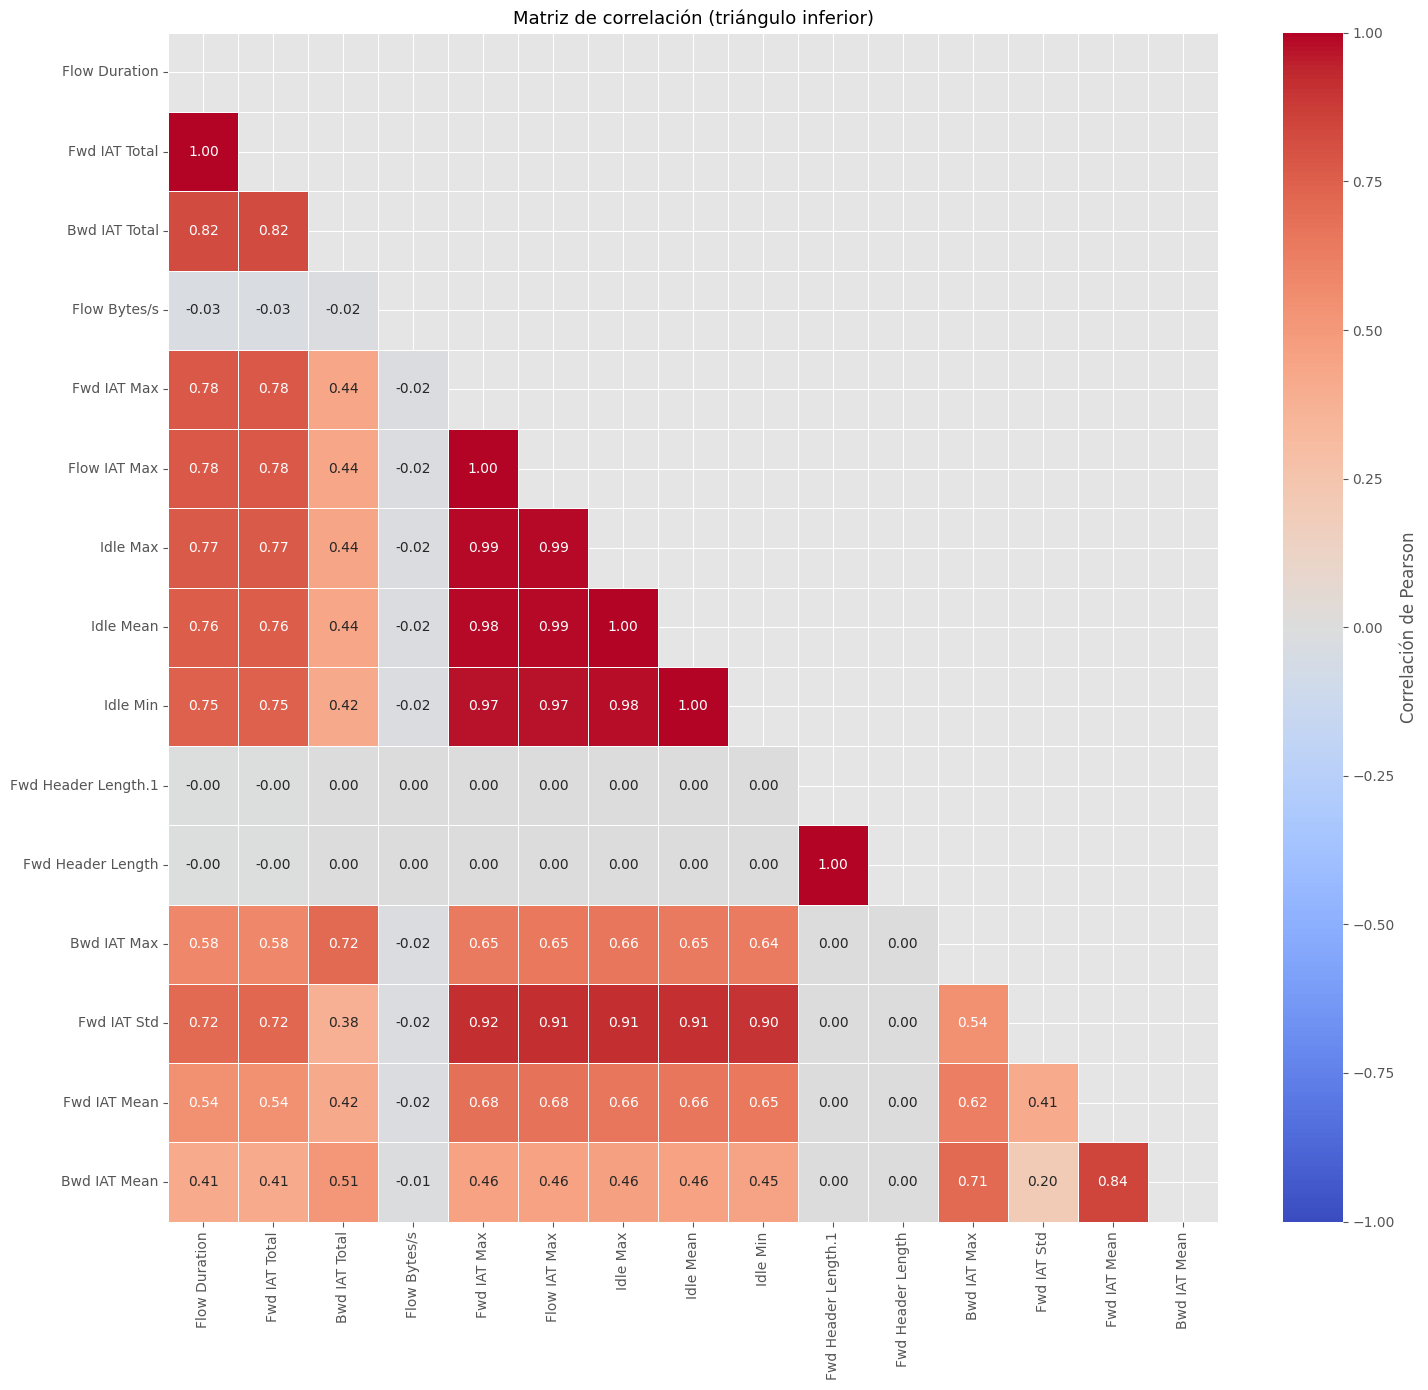

In [17]:
corr = df[feat_num].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # triángulo superior

fig, ax = plt.subplots(figsize=(max(8, len(feat_num)), max(6, len(feat_num) - 1)))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Correlación de Pearson'},
    ax=ax,
)
ax.set_title('Matriz de correlación (triángulo inferior)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix_2d.png', dpi=150)
plt.show()


Flow IAT Max, Idle Max, Idle Mean, Idle Min están prácticamente duplicando información (correlaciones ~0.97–1.00).
Fwd IAT Total y Bwd IAT Total también están fuertemente correlacionadas (~0.82) → probablemente redundantes en parte.
Fwd IAT Max y Flow IAT Max tienen correlación perfecta (1.00)
Flow Bytes/s está prácticamente descorrelacionada de todo
Fwd Header Length y su duplicado (.1)
Bwd IAT Max tiene correlaciones moderadas (0.6–0.7) con varios → aporta algo distinto, no es redundante total
Fwd IAT Std está muy correlacionada (~0.9) con los Idle → probablemente mide lo mismo de otra forma

### 6.2 Mapa de calor 3D (Plotly Surface)

In [18]:
corr_vals = corr.values
labels    = corr.columns.tolist()
n         = len(labels)

# Superficie 3D: cada celda de la matriz de correlación se representa como altura
fig_3d = go.Figure(data=[
    go.Surface(
        z=corr_vals,
        x=labels,
        y=labels,
        colorscale='RdBu_r',
        cmin=-1, cmax=1,
        colorbar=dict(title='Correlación', thickness=15),
        hovertemplate='<b>%{x}</b> × <b>%{y}</b><br>r = %{z:.3f}<extra></extra>',
    )
])

fig_3d.update_layout(
    title=dict(text='Matriz de correlación 3D', font=dict(size=18)),
    scene=dict(
        xaxis=dict(title='', tickangle=-45, tickfont=dict(size=9)),
        yaxis=dict(title='', tickfont=dict(size=9)),
        zaxis=dict(title='Correlación', range=[-1, 1]),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.2)),
    ),
    width=850, height=600,
    margin=dict(l=0, r=0, b=0, t=50),
)

fig_3d.show()
fig_3d.write_html(str(FIGURES_DIR / 'correlation_3d.html'))
print('Guardado: correlation_3d.html')


Guardado: correlation_3d.html


### 6.3 Correlaciones altas (umbral configurable)

In [19]:
CORR_THRESHOLD = 0.75  # ← ajusta

corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['Var1', 'Var2', 'Correlación']
corr_pairs['AbsCorr'] = corr_pairs['Correlación'].abs()
high_corr = corr_pairs[corr_pairs['AbsCorr'] >= CORR_THRESHOLD].sort_values('AbsCorr', ascending=False)

if high_corr.empty:
    print(f'Sin pares con |r| ≥ {CORR_THRESHOLD}')
else:
    print(f'Pares con |r| ≥ {CORR_THRESHOLD}:')
    display(high_corr[['Var1','Var2','Correlación']].style.background_gradient(
        cmap='RdYlGn', subset=['Correlación']
    ).format({'Correlación': '{:.3f}'}))


Pares con |r| ≥ 0.75:


,Var1,Var2,Correlación
54,Fwd Header Length,Fwd Header Length.1,1.000
0,Fwd IAT Total,Flow Duration,0.999
14,Flow IAT Max,Fwd IAT Max,0.999
35,Idle Min,Idle Mean,0.996
27,Idle Mean,Idle Max,0.996
20,Idle Max,Flow IAT Max,0.989
19,Idle Max,Fwd IAT Max,0.989
26,Idle Mean,Flow IAT Max,0.985
25,Idle Mean,Fwd IAT Max,0.985
34,Idle Min,Idle Max,0.984


## 7. Detección de outliers

Se usan tres métodos complementarios:

| Método | Supuesto | Cuándo usarlo |
|---|---|---|
| **IQR** | No paramétrico | Siempre, especialmente con sesgos |
| **Z-score** | Distribución normal | Variables aproximadamente normales |
| **Isolation Forest** | Sin supuestos | Outliers multivariantes complejos |

### 7.1 Boxplots (visión rápida)

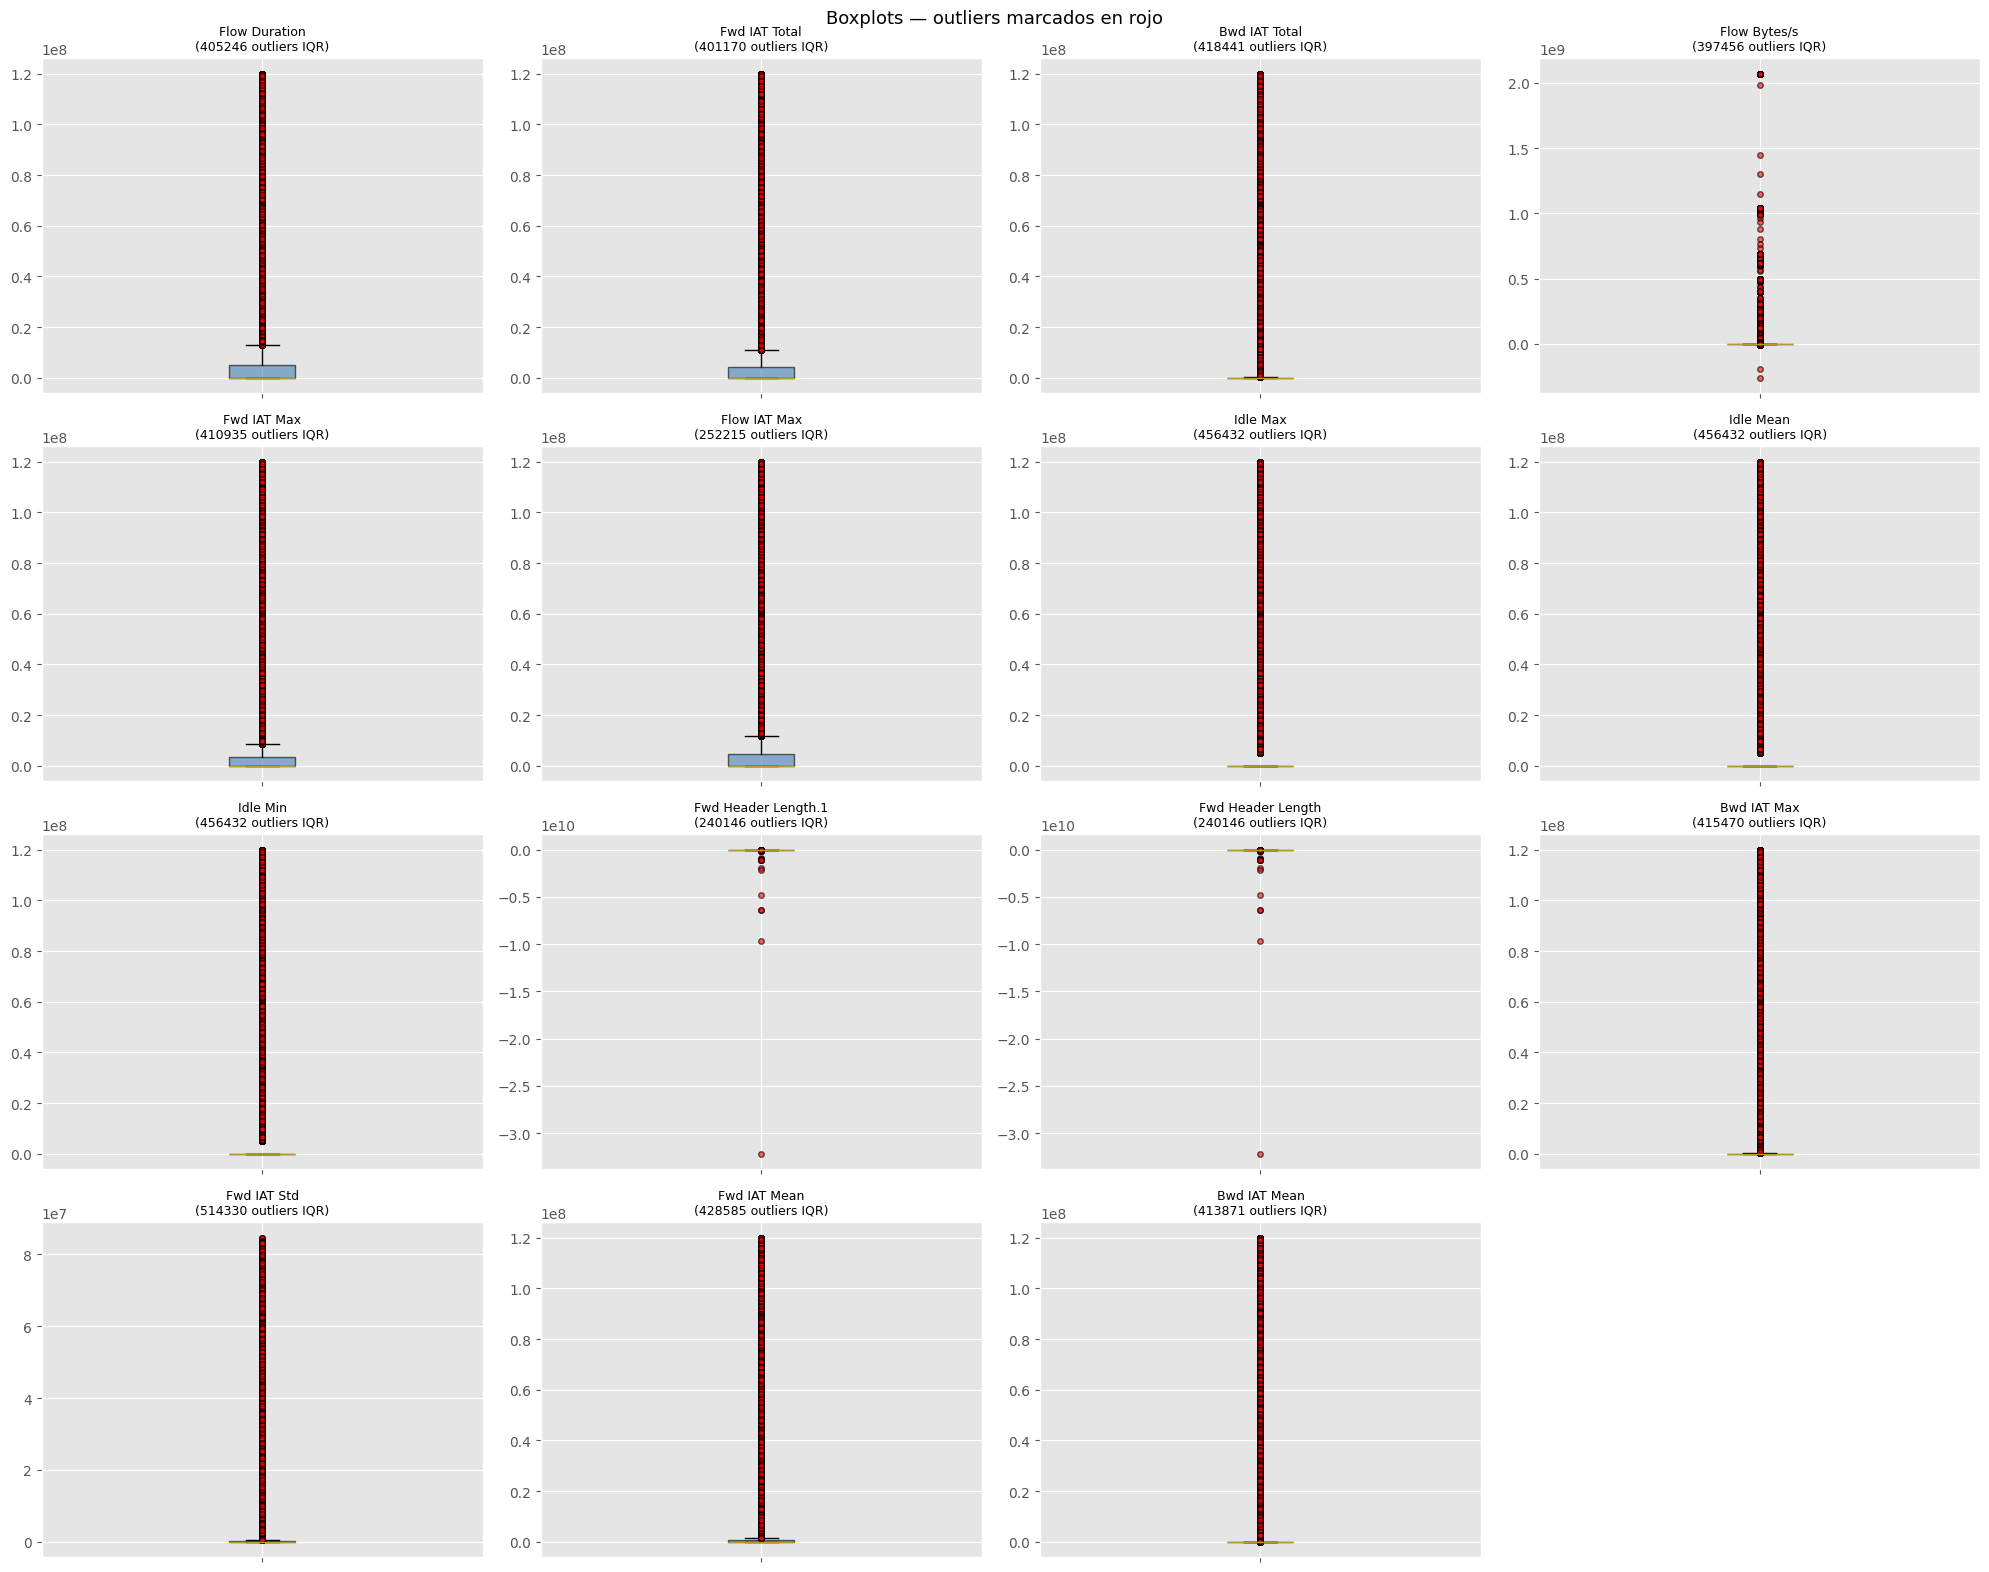

In [20]:
if feat_num:
    n_cols_plot = min(4, len(feat_num))
    n_rows_plot = int(np.ceil(len(feat_num) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(5 * n_cols_plot, 4 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(feat_num):
        data = df[col].dropna()
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr  = q3 - q1
        low  = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((data < low) | (data > high)).sum()

        bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                             flierprops=dict(marker='o', markerfacecolor='red',
                                            markersize=4, alpha=0.6))
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][0].set_alpha(0.6)
        axes[i].set_title(f'{col}\n({n_out} outliers IQR)', fontsize=9)
        axes[i].set_xticklabels([])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Boxplots — outliers marcados en rojo', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'boxplots.png', dpi=150)
    plt.show()


### 7.2 IQR — resumen cuantitativo

In [21]:
iqr_results = []
for col in feat_num:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr  = q3 - q1
    low  = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask_out = (data < low) | (data > high)
    iqr_results.append({
        'Variable':    col,
        'Q1':          round(q1, 3),
        'Q3':          round(q3, 3),
        'IQR':         round(iqr, 3),
        'Límite_inf':  round(low, 3),
        'Límite_sup':  round(high, 3),
        'N_outliers':  int(mask_out.sum()),
        'Pct_outliers': f'{mask_out.mean():.1%}',
    })

df_iqr = pd.DataFrame(iqr_results).sort_values('N_outliers', ascending=False)
df_iqr.style.background_gradient(cmap='Oranges', subset=['N_outliers'])


,Variable,Q1,Q3,IQR,Límite_inf,Límite_sup,N_outliers,Pct_outliers
12,Fwd IAT Std,0.000000,163962.318000,163962.318000,-245943.477000,409905.795000,514330,24.1%
7,Idle Mean,0.000000,0.000000,0.000000,0.000000,0.000000,456432,21.4%
6,Idle Max,0.000000,0.000000,0.000000,0.000000,0.000000,456432,21.4%
8,Idle Min,0.000000,0.000000,0.000000,0.000000,0.000000,456432,21.4%
13,Fwd IAT Mean,0.000000,650648.000000,650648.000000,-975972.000000,1626620.000000,428585,20.1%
2,Bwd IAT Total,0.000000,138390.000000,138390.000000,-207585.000000,345975.000000,418441,19.6%
11,Bwd IAT Max,0.000000,83178.500000,83178.500000,-124767.750000,207946.250000,415470,19.5%
14,Bwd IAT Mean,0.000000,24479.917000,24479.917000,-36719.875000,61199.792000,413871,19.4%
4,Fwd IAT Max,0.000000,3436969.500000,3436969.500000,-5155454.250000,8592423.750000,410935,19.3%
0,Flow Duration,190.000000,5154965.500000,5154775.500000,-7731973.250000,12887128.750000,405246,19.0%


### 7.3 Z-score (umbral = 3)

In [22]:
Z_THRESHOLD = 3  # ← outlier si |z| > 3

z_results = []
for col in feat_num:
    data = df[col].dropna()
    z    = np.abs(stats.zscore(data))
    n_out = (z > Z_THRESHOLD).sum()
    z_results.append({'Variable': col, 'N_outliers_z': int(n_out),
                      'Pct': f'{n_out/len(data):.1%}',
                      'Max_|z|': round(z.max(), 2)})

df_z = pd.DataFrame(z_results).sort_values('N_outliers_z', ascending=False)
df_z.style.background_gradient(cmap='Reds', subset=['N_outliers_z'])


,Variable,N_outliers_z,Pct,Max_|z|
2,Bwd IAT Total,112382,5.3%,3.520000
12,Fwd IAT Std,110171,5.2%,7.820000
5,Flow IAT Max,99380,4.7%,4.200000
4,Fwd IAT Max,99365,4.7%,4.200000
6,Idle Max,98966,4.6%,4.230000
8,Idle Min,96755,4.5%,4.330000
7,Idle Mean,95782,4.5%,4.300000
11,Bwd IAT Max,74567,3.5%,6.190000
14,Bwd IAT Mean,35317,1.7%,12.270000
13,Fwd IAT Mean,33049,1.6%,11.400000


### 7.4 Isolation Forest — outliers multivariantes 

Isolation Forest detecta outliers que son anómalos en el **espacio multidimensional** completo,
no variable a variable. Es especialmente útil para detectar combinaciones raras de valores
que individualmente parecen normales.

In [23]:
CONTAMINATION = 0.05  # ← % esperado de outliers en el dataset

X_num = df[feat_num].dropna()
scaler_iso = StandardScaler()
X_scaled   = scaler_iso.fit_transform(X_num)

iso = IsolationForest(
    contamination=CONTAMINATION,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_scaled)

scores    = iso.decision_function(X_scaled)   # más negativo = más outlier
labels_if = iso.predict(X_scaled)             # -1 = outlier, 1 = normal

n_outliers = (labels_if == -1).sum()
print(f'Isolation Forest → {n_outliers} outliers detectados ({n_outliers/len(X_num):.1%})')

df_iso = X_num.copy()
df_iso['iso_score']  = scores
df_iso['iso_outlier'] = labels_if == -1


Isolation Forest → 106507 outliers detectados (5.0%)


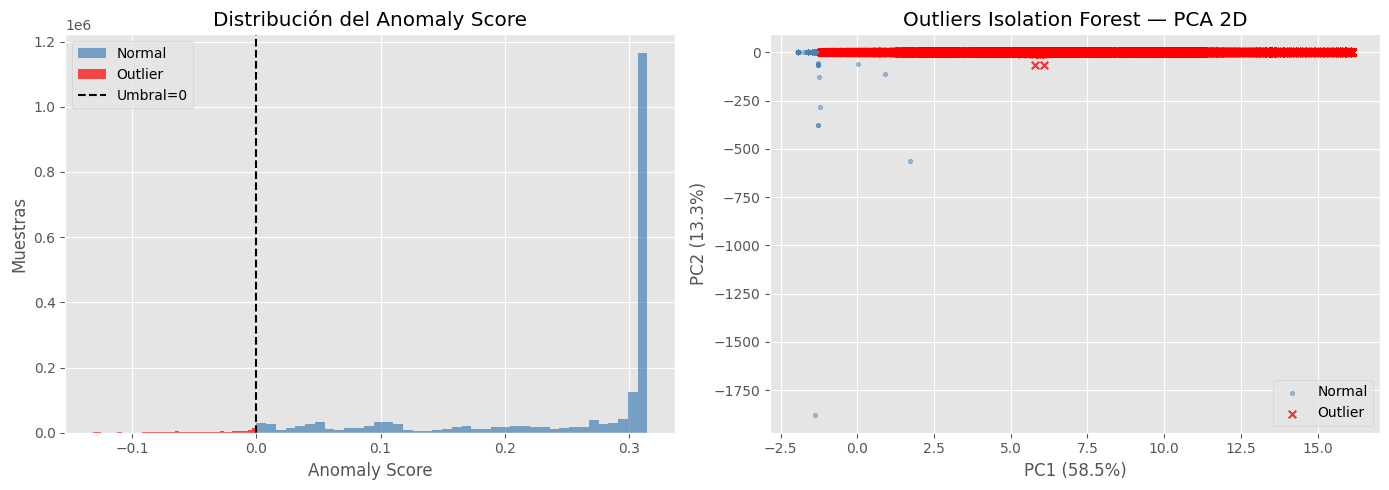

In [24]:
# Visualización del anomaly score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del score
axes[0].hist(scores[labels_if ==  1], bins=40, alpha=0.7, color='steelblue', label='Normal')
axes[0].hist(scores[labels_if == -1], bins=40, alpha=0.7, color='red',       label='Outlier')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--', label='Umbral=0')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Muestras')
axes[0].set_title('Distribución del Anomaly Score')
axes[0].legend()

# PCA 2D para visualizar separación
from sklearn.decomposition import PCA
pca_iso = PCA(n_components=2)
X_pca   = pca_iso.fit_transform(X_scaled)

axes[1].scatter(X_pca[labels_if ==  1, 0], X_pca[labels_if ==  1, 1],
                c='steelblue', s=10, alpha=0.5, label='Normal')
axes[1].scatter(X_pca[labels_if == -1, 0], X_pca[labels_if == -1, 1],
                c='red', s=30, alpha=0.8, marker='x', label='Outlier', linewidths=1.5)
axes[1].set_xlabel(f'PC1 ({pca_iso.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_iso.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Outliers Isolation Forest — PCA 2D')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'isolation_forest.png', dpi=150)
plt.show()


El PCA 2D lo confirma — los "outliers" (rojo) están pegados a la línea horizontal junto a los normales, no son puntos aislados reales. Los puntos azules dispersos hacia abajo son los valores negativos imposibles de las columnas corruptas.

In [25]:
# Top 10 outliers más extremos
top_outliers = df_iso[df_iso['iso_outlier']].sort_values('iso_score').head(10)
print('Top 10 outliers más extremos:')
display(top_outliers.drop(columns=['iso_score','iso_outlier']).style.highlight_max(axis=0, color='#ffcccc'))


Top 10 outliers más extremos:


,Flow Duration,Fwd IAT Total,Bwd IAT Total,Flow Bytes/s,Fwd IAT Max,Flow IAT Max,Idle Max,Idle Mean,Idle Min,Fwd Header Length.1,Fwd Header Length,Bwd IAT Max,Fwd IAT Std,Fwd IAT Mean,Bwd IAT Mean
343876,119194852,119078978,119162766,2.877641,119078978,119046892,119046892,119046892.000000,119046892,40,40,119162766,0.000000,119078978.000000,119162766.000000
596389,119784071,119721546,119722651,2.905228,119721546,119660126,119660126,119660126.000000,119660126,40,40,119722651,0.000000,119721546.000000,119722651.000000
1442540,119441981,119000000,119000000,2.787964,119000000,119000000,119000000,119000000.000000,119000000,40,40,119000000,0.000000,119000000.000000,119000000.000000
1764968,119608954,120000000,120000000,2.474731,120000000,119000000,119000000,119000000.000000,119000000,40,40,120000000,0.000000,120000000.000000,120000000.000000
1377132,119641498,120000000,120000000,3.594071,120000000,120000000,120000000,120000000.000000,120000000,40,40,120000000,0.000000,120000000.000000,120000000.000000
1376478,119259240,119000000,119000000,3.052174,119000000,119000000,119000000,119000000.000000,119000000,40,40,119000000,0.000000,119000000.000000,119000000.000000
1319455,119635903,120000000,120000000,2.892108,120000000,120000000,120000000,120000000.000000,120000000,40,40,120000000,0.000000,120000000.000000,120000000.000000
1533201,119487920,119000000,119000000,2.025309,119000000,119000000,119000000,119000000.000000,119000000,40,40,119000000,0.000000,119000000.000000,119000000.000000
1778536,119073073,119000000,119000000,3.468458,119000000,119000000,119000000,119000000.000000,119000000,40,40,119000000,0.000000,119000000.000000,119000000.000000
2112918,119542086,120000000,119000000,3.546868,120000000,119000000,119000000,119000000.000000,119000000,40,40,119000000,0.000000,120000000.000000,119000000.000000


In [26]:
print(df.loc[[343876, 596389, 1442540], 'Label'].values)

['BENIGN' 'BENIGN' 'BENIGN']


Son conexiones idle o keepalive — no ataques, no corrupción. El Isolation Forest los detecta como anómalos porque son estadísticamente raros, pero son tráfico legítimo de larga duración.
Decisión: no eliminar. Son BENIGN casi con seguridad. El modelo aprenderá que flujos muy largos con Idle alto son normales.

### 7.5 Comparativa IQR vs Z-score vs Isolation Forest

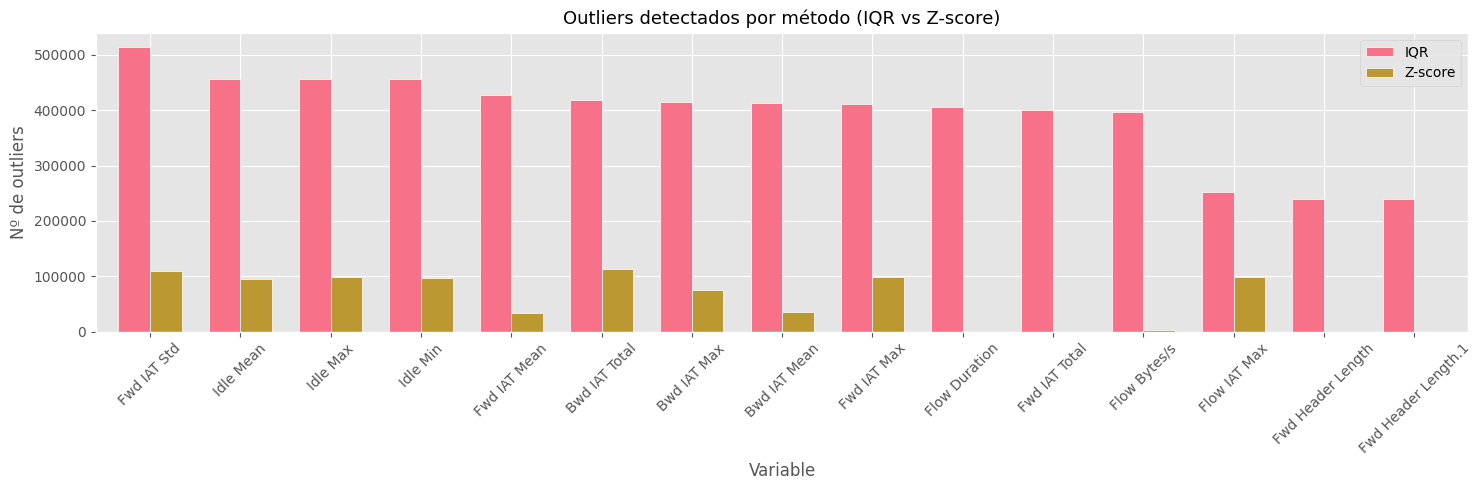

In [27]:
# Comparativa del número de outliers detectados por cada método
compare = df_iqr[['Variable','N_outliers']].rename(columns={'N_outliers': 'IQR'})
compare = compare.merge(
    df_z[['Variable','N_outliers_z']].rename(columns={'N_outliers_z': 'Z-score'}),
    on='Variable'
).set_index('Variable')

fig, ax = plt.subplots(figsize=(max(8, len(feat_num)), 5))
compare.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Outliers detectados por método (IQR vs Z-score)', fontsize=13)
ax.set_ylabel('Nº de outliers')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outliers_comparison.png', dpi=150)
plt.show()


Del IQR vs Z-score — mismo patrón que fraud-shield, IQR completamente roto con estas distribuciones. No eliminar nada por este método.

## 8. Violin plots

Combinan la información del boxplot con la distribución real (KDE lateral).
Son especialmente útiles cuando hay multimodalidad que el boxplot no muestra.

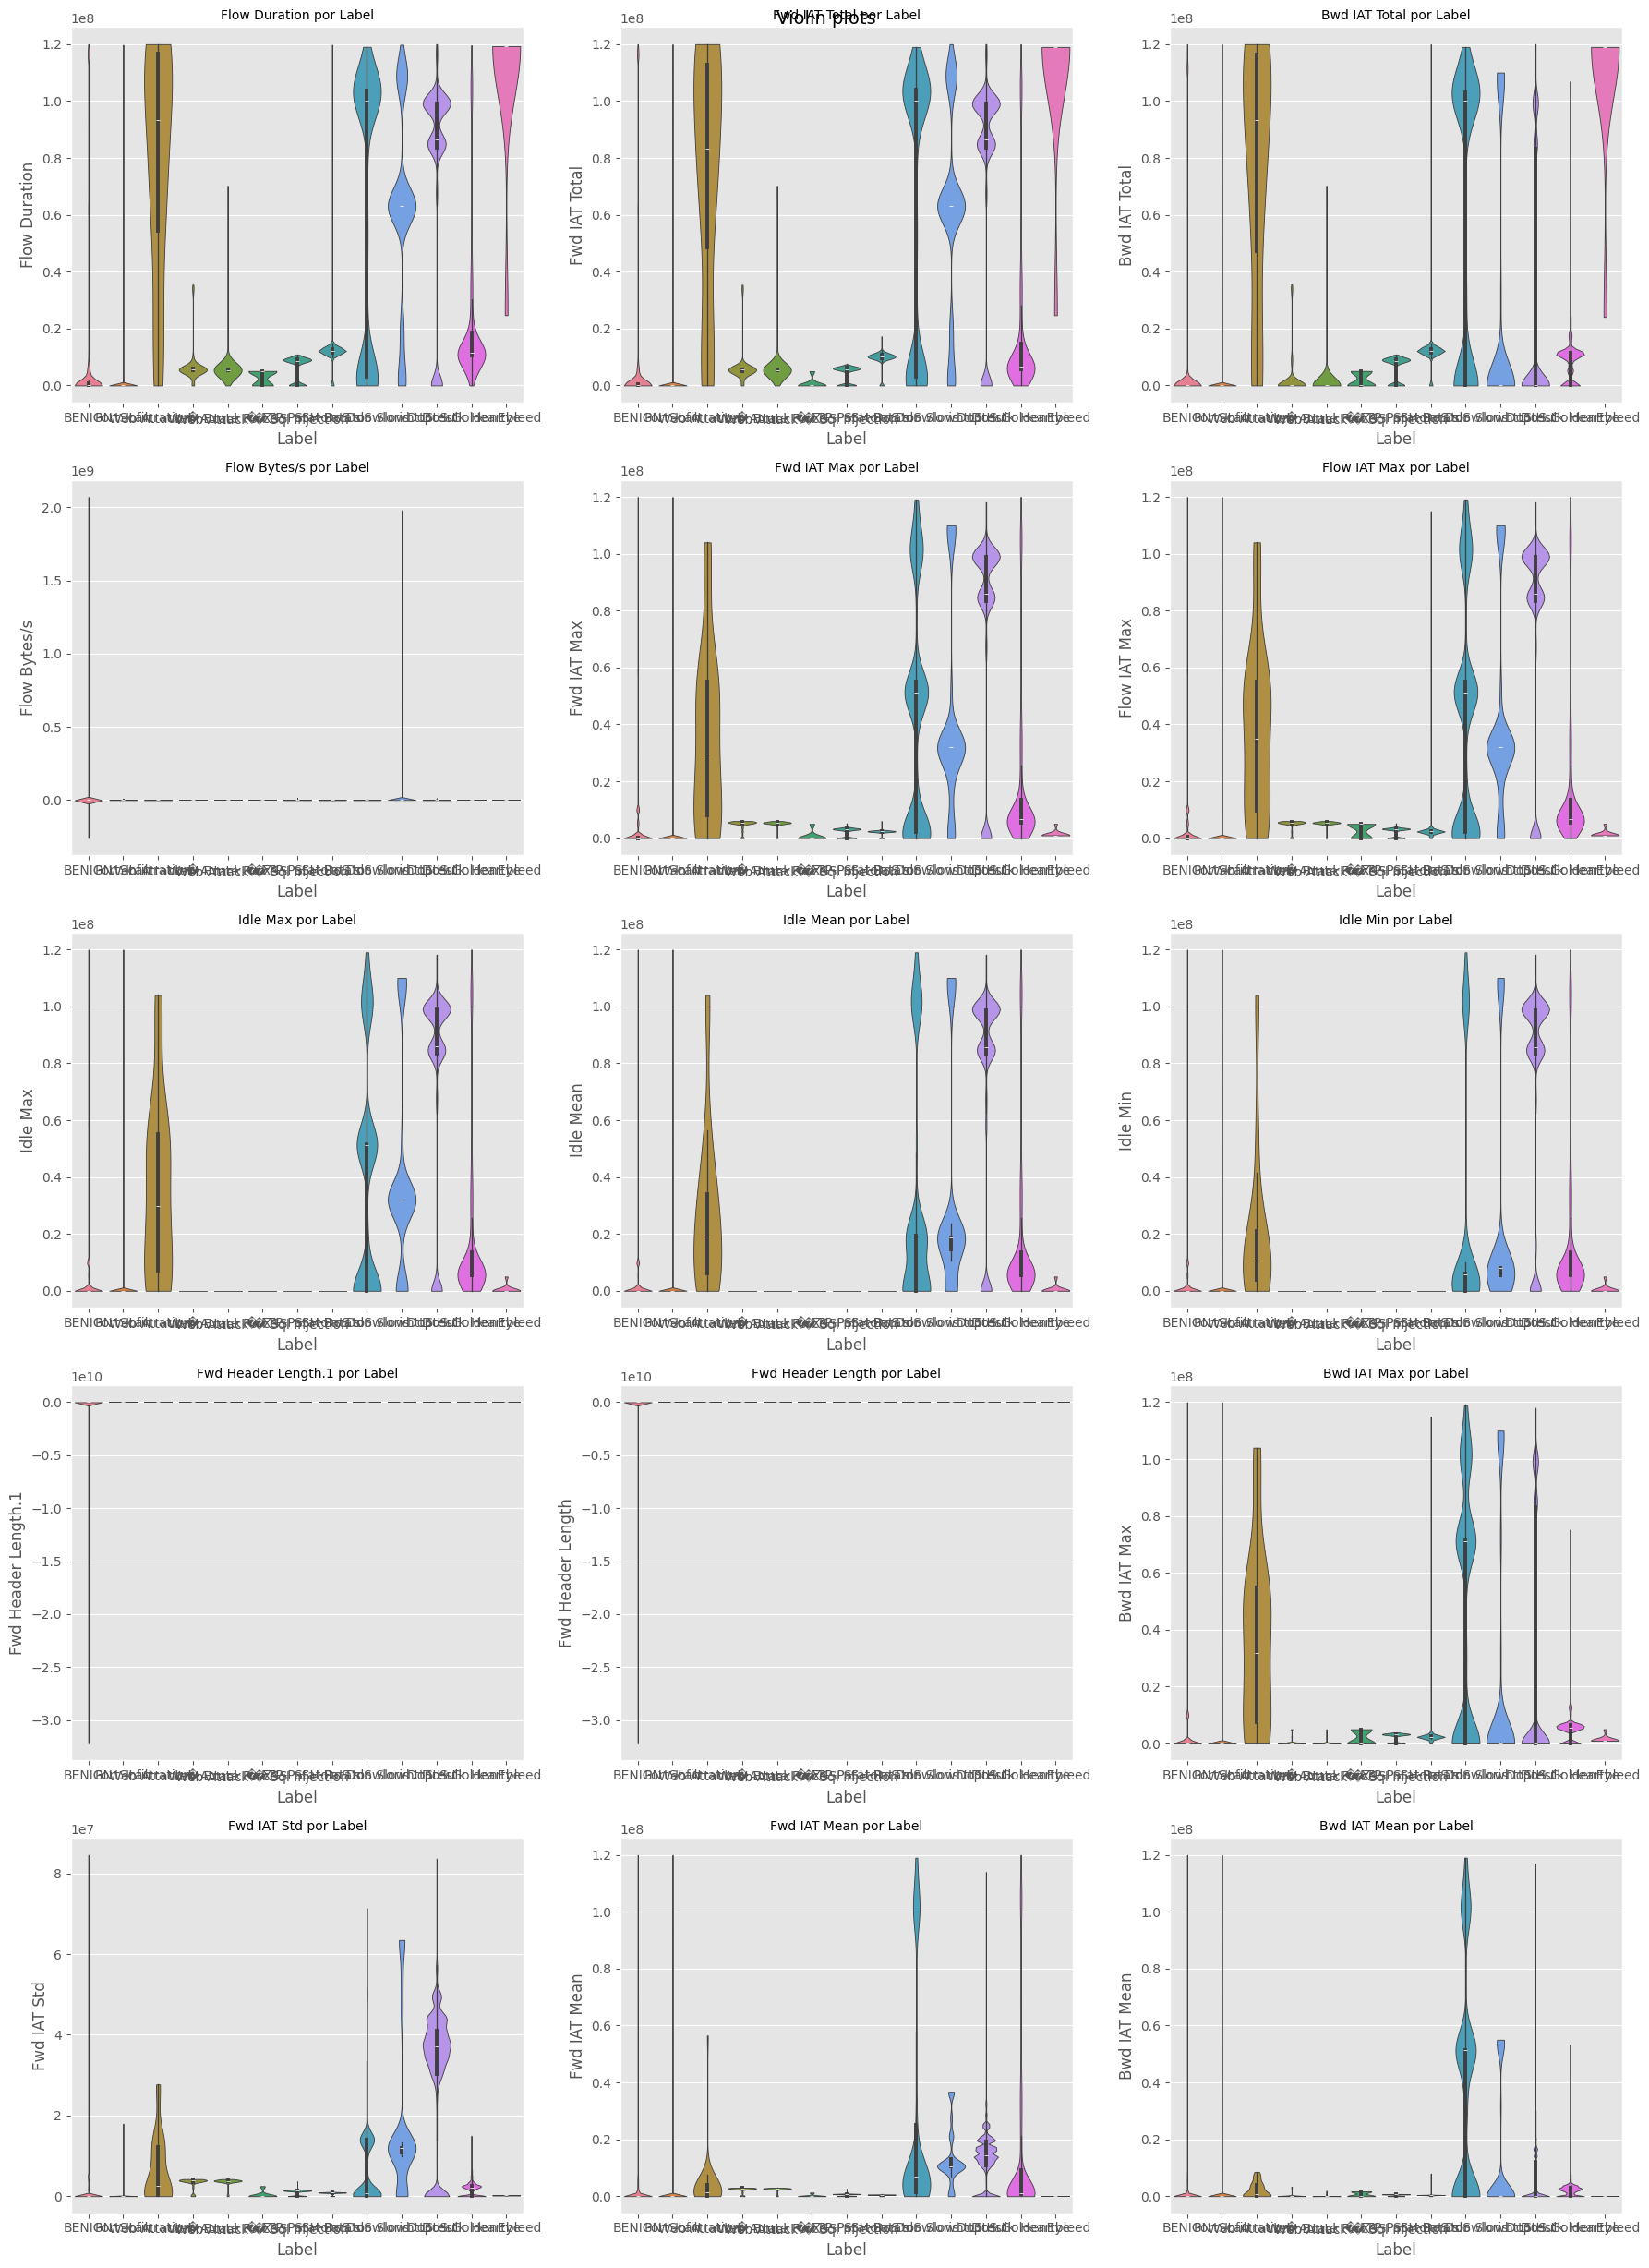

In [28]:
if feat_num:
    n_cols_plot = min(3, len(feat_num))
    n_rows_plot = int(np.ceil(len(feat_num) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(6 * n_cols_plot, 5 * n_rows_plot))
    axes = np.array(axes).ravel()


    hue_col = TARGET_COL if TARGET_COL and TARGET_COL in df.columns else None


    for i, col in enumerate(feat_num):
        if hue_col:
            sns.violinplot(
                data=df, x=hue_col, y=col,
                ax=axes[i], inner='box', palette='husl',
                cut=0, density_norm='width',
            )
            axes[i].set_title(f'{col} por {hue_col}', fontsize=10)
        else:
            sns.violinplot(
                data=df, y=col, ax=axes[i],
                inner='box', color='steelblue', cut=0,
            )
            axes[i].set_title(col, fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Violin plots', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'violin_plots.png', dpi=150)
    plt.show()


Features discriminativas claras:
Flow Duration — BENIGN tiene distribución muy amplia, la mayoría de ataques (DoS, PortScan) están aplastados cerca de 0. Señal fuerte.
Fwd IAT Total y Bwd IAT Total — mismo patrón. Ataques tienen tiempos inter-arrival muy cortos — típico de tráfico automatizado/flooding.
Idle Max/Mean/Min — BENIGN tiene valores altos (conexiones reales con pausas), ataques tienen idle=0. Feature muy discriminativa.
Fwd IAT Mean y Bwd IAT Mean — ataques DoS y PortScan aplastados a 0, BENIGN disperso. Señal clara.
Features poco discriminativas:
Fwd Header Length y Fwd Header Length.1 — todas las clases aplastadas en el mismo rango negativo corrupto. Drop confirmado.
Flow Bytes/s — ilegible por los infinitos. Drop confirmado.

## 9. Pairplot interactivo (Plotly)

Scatter matrix de todas las variables numéricas. Permite detectar:
- Relaciones lineales y no lineales
- Grupos o clusters visuales
- Outliers en el espacio 2D de cada par de variables

In [ ]:
MAX_PAIR_FEATURES = 6  # limitar para que no sea lentísimo con muchas variables
pair_cols = feat_num[:MAX_PAIR_FEATURES]


color_col = TARGET_COL if TARGET_COL and TARGET_COL in df.columns else None


fig_pair = px.scatter_matrix(
    df[pair_cols + ([color_col] if color_col else [])].dropna(),
    dimensions=pair_cols,
    color=color_col,
    title='Scatter Matrix (pairplot interactivo)',
    opacity=0.5,
    height=800,
)
fig_pair.update_traces(diagonal_visible=False, marker=dict(size=3))
fig_pair.show()
fig_pair.write_html(str(FIGURES_DIR / 'pairplot_interactive.html'))
print('Guardado: pairplot_interactive.html')


Correlación altísima entre features temporales — Flow Duration, Fwd IAT Total, Bwd IAT Total, Fwd IAT Max, Flow IAT Max forman líneas diagonales casi perfectas entre sí. Son prácticamente la misma información. Candidatas a reducir — podrías quedarte solo con Flow Duration y Fwd IAT Total y dropear las demás.
Flow Bytes/s — columna vertical aplastada, confirma los infinitos. Drop definitivo.
Separación por clases clara — los puntos rojos (DoS Hulk/GoldenEye) están concentrados en la esquina inferior izquierda — flujos muy cortos. BENIGN (azul) ocupa todo el espacio. PortScan disperso. Esto confirma que las features temporales discriminan bien los ataques DoS.
Infiltration, Web Attacks, Heartbleed — prácticamente invisibles por el desbalance extremo (36, 652, 11 muestras). Esas clases van a ser muy difíciles de clasificar.

In [ ]:
# Pairplot estático seaborn (para guardar PNG)

hue_pair = TARGET_COL if TARGET_COL and TARGET_COL in df.columns else None


g = sns.pairplot(
    df[pair_cols + ([hue_pair] if hue_pair else [])].dropna(),
    hue=hue_pair,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kws={'fill': True},
)
g.figure.suptitle('Pairplot — primeras variables numéricas', y=1.02, fontsize=13)
g.figure.savefig(FIGURES_DIR / 'pairplot.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Variables categóricas

In [ ]:

plot_cat = [c for c in cat_cols if c != TARGET_COL]


if plot_cat:
    n_cols_plot = min(3, len(plot_cat))
    n_rows_plot = int(np.ceil(len(plot_cat) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(6 * n_cols_plot, 4 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(plot_cat):
        vc = df[col].value_counts().head(15)  # top 15 valores
        vc.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='white')
        axes[i].set_title(f'{col} (top 15)', fontsize=10)
        axes[i].set_xlabel('Frecuencia')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribución de variables categóricas', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'categorical.png', dpi=150)
    plt.show()
else:
    print('Sin variables categóricas')


In [ ]:

# Categóricas vs target: stacked bar normalizado
if plot_cat and TARGET_COL and TARGET_COL in df.columns:
    n_cols_plot = min(2, len(plot_cat))
    n_rows_plot = int(np.ceil(len(plot_cat) / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                             figsize=(8 * n_cols_plot, 5 * n_rows_plot))
    axes = np.array(axes).ravel()

    for i, col in enumerate(plot_cat):
        ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[i], edgecolor='white', width=0.8)
        axes[i].set_title(f'{col} vs {TARGET_COL}', fontsize=10)
        axes[i].set_ylabel('%')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Categóricas vs {TARGET_COL} (stacked %)', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'categorical_vs_target.png', dpi=150)
    plt.show()



## 11. Resumen automático de calidad del dataset

In [ ]:
total_cells = df.shape[0] * df.shape[1]
null_cells  = df.isnull().sum().sum()
dup_rows    = df.duplicated().sum()

# Outliers IQR totales
total_iqr_out = sum(
    ((df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
     (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))).sum()
    for col in feat_num
)

high_corr_pairs = len(high_corr)
skewed_cols = (df[feat_num].skew().abs() > 1).sum()

print('═' * 50)
print('   RESUMEN DE CALIDAD DEL DATASET')
print('═' * 50)
print(f'  Filas × columnas   : {df.shape[0]:,} × {df.shape[1]}')
print(f'  Memoria            : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
print(f'  Celdas nulas       : {null_cells:,} ({null_cells/total_cells:.1%})')
print(f'  Filas duplicadas   : {dup_rows:,} ({dup_rows/len(df):.1%})')
print(f'  Outliers IQR total : {total_iqr_out:,}')
print(f'  Outliers Iso.Forest: {n_outliers:,} ({n_outliers/len(df):.1%})')
print(f'  Pares alta corr.   : {high_corr_pairs} (|r|≥{CORR_THRESHOLD})')
print(f'  Variables sesgadas : {skewed_cols} (|skew|>1)')

if TARGET_COL and TARGET_COL in df.columns:
    vc = df[TARGET_COL].value_counts(normalize=True)
    imbalance = vc.max() / vc.min() if len(vc) > 1 else 1
    print(f'  Desbalanceo target : {imbalance:.1f}x ({vc.idxmax()} domina)')

print('═' * 50)
